In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
from mpl_toolkits.mplot3d import Axes3D 
from matplotlib.colors import LogNorm
import matplotlib.colors as mcolors 

In [3]:
parts = pd.read_hdf("../config/ATPC_Bi_ion_cathode.h5", "MC/particles")

In [4]:
parts = parts[parts.primary == 1]
parts.describe()

,event_id,particle_id,primary,mother_id,initial_x,initial_y,initial_z,initial_t,final_x,final_y,final_z,final_t,initial_momentum_x,initial_momentum_y,initial_momentum_z,final_momentum_x,final_momentum_y,final_momentum_z,kin_energy,length
count,560.000000,560.0,560.0,560.0,560.000000,560.000000,560.000000,560.0,560.000000,560.000000,560.000000,560.000000,560.0,560.0,560.0,560.0,560.0,560.0,560.0,560.0
mean,10079.500000,1.0,1.0,0.0,-1.722881,15.259275,-1434.999512,0.0,-1.722881,15.259275,-1434.999512,0.000950,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
std,161.802349,0.0,0.0,0.0,698.320618,678.313782,0.000487,0.0,698.320618,678.313782,0.000487,0.000931,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,9800.000000,1.0,1.0,0.0,-1405.195557,-1393.190308,-1435.000000,0.0,-1405.195557,-1393.190308,-1435.000000,0.000004,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,9939.750000,1.0,1.0,0.0,-539.015396,-496.261040,-1434.999756,0.0,-539.015396,-496.261040,-1434.999756,0.000263,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,10079.500000,1.0,1.0,0.0,23.060177,11.588599,-1434.999512,0.0,23.060177,11.588599,-1434.999512,0.000633,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,10219.250000,1.0,1.0,0.0,555.960815,574.844055,-1434.999268,0.0,555.960815,574.844055,-1434.999268,0.001399,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,10359.000000,1.0,1.0,0.0,1388.354736,1395.396362,-1434.999023,0.0,1388.354736,1395.396362,-1434.999023,0.006428,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


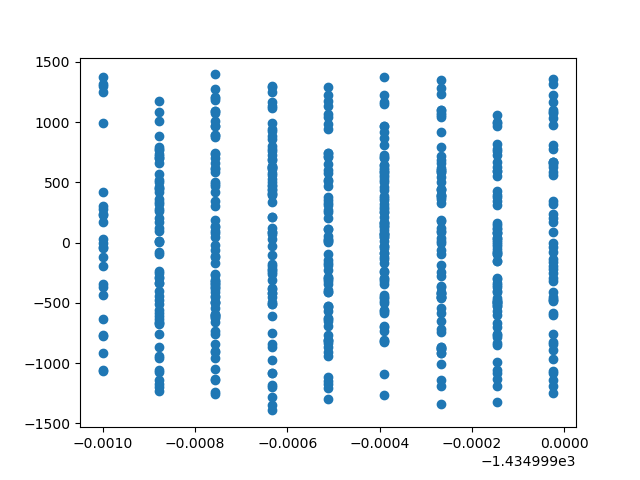

In [5]:
%matplotlib widget
plt.figure()

plt.scatter(parts.initial_z, parts.initial_y)
# plt.scatter(parts.initial_x, parts.initial_y)
# plt.xlim(-3.5e3,0)

event_id
9800     2.310251
9801     2.331263
9802     2.324900
9803     2.454787
9804     2.546292
           ...   
10355    2.370565
10356    2.406625
10357    2.392954
10358    2.492887
10359    2.303766
Name: energy, Length: 560, dtype: float32


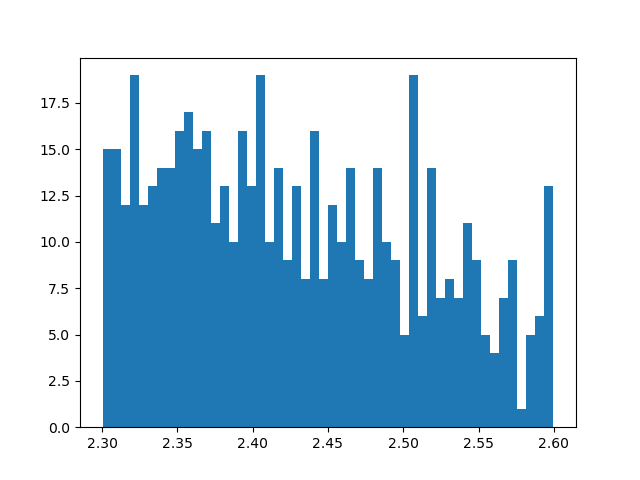

In [6]:
hits = pd.read_hdf("../config/ATPC_Bi_ion_cathode.h5", "MC/hits")

energysum = hits.groupby("event_id").energy.sum()
print(energysum)

plt.figure()
plt.hist(energysum, bins =50);

In [10]:
radon = pd.read_hdf("../data/test/ATPC_Bi_ion_cathode_1bar_5percent_reco.h5", "data")

# Load the dictionary back from the pickle file (binary mode)
with open("../data/test/ATPC_Bi_ion_cathode_1bar_5percent_trackreco.pkl", 'rb') as pickle_file:  # Use 'rb' for reading in binary
    Tracks_radon      = pickle.load(pickle_file)
    connections_radon = pickle.load(pickle_file)
    connection_counts_radon = pickle.load(pickle_file)



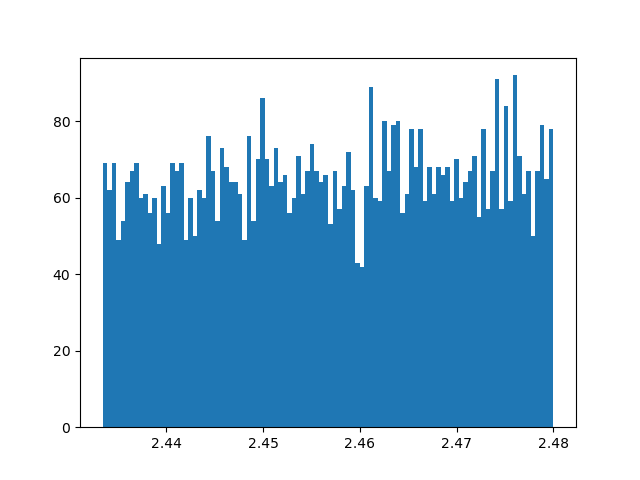

In [ ]:
# display(radon)

energies = radon.groupby("event_id").energy.sum()
# print(energies)
plt.figure()

plt.hist(energies, bins = 100);


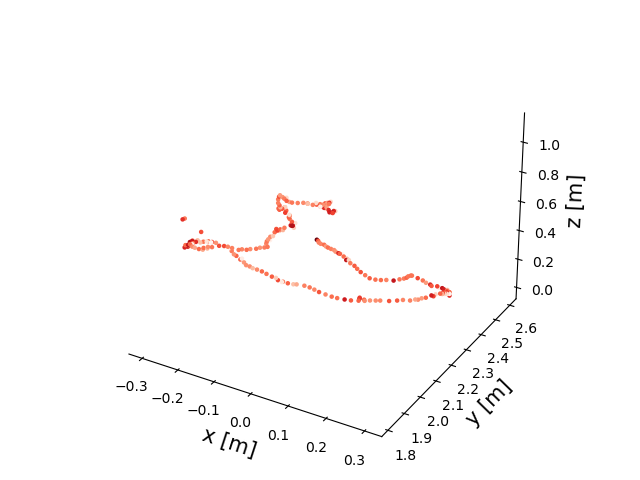

In [25]:
# 3D event display
%matplotlib widget


ids = radon.event_id.unique()
id_ = ids[6]
# id_ = 200008

event = radon[radon.event_id == id_]

ax = plt.figure().add_subplot(projection='3d')

ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

# ax.scatter(event.x/1000,event.y/1000, event.z/1000, c = event.energy, s = 5, cmap='BuGn', alpha=1, norm=mcolors.LogNorm())
ax.scatter(event.x/1000,event.y/1000, event.z/1000, c = event.energy, s = 5, cmap='Reds', alpha=1, norm=mcolors.LogNorm())


ax.set_xlabel("x [m]", fontsize = 15)
ax.set_ylabel("y [m]", fontsize = 15)
ax.set_zlabel("z [m]", fontsize = 15)
ax.tick_params(axis='both', which='both', labelsize=10)  # Adjust labelsize as needed

# Remove the background grid panes and gridlines
ax.xaxis.pane.set_edgecolor('none')  # Removes the edges
ax.yaxis.pane.set_edgecolor('none')
ax.zaxis.pane.set_edgecolor('none')
ax.xaxis.pane.set_visible(False)  # Removes the background pane
ax.yaxis.pane.set_visible(False)
ax.zaxis.pane.set_visible(False)
ax.grid(False)  # Remove the gridlines

plt.tight_layout()
